# 📘 CIFAR-10 Image Classification Learning Project
## Build and Compare **ANN vs CNN** on CIFAR-10

This notebook is designed for **students and beginners** to learn:
- How image classification works
- Why **CNN performs better than ANN**
- How architecture impacts performance
- How training strategies improve results

🎯 **Learning Goal:** Understand the complete DL pipeline by **reading the markdown + running the ready code**.

# 🧠 Problem Statement
Build an image classification model on the **CIFAR-10 dataset** using:

1. **Artificial Neural Network (ANN)**
2. **Convolutional Neural Network (CNN)**

Then compare:
- Accuracy
- Loss curves
- Generalization
- Training strategies (dropout, batch norm, augmentation)

---
### 📦 CIFAR-10 Classes
Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


# 📥 Load Dataset
We use **CIFAR-10**, which contains **60,000 color images of size 32×32×3**.
- 50,000 training images
- 10,000 test images

In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


## 🖼️ Visualize Sample Images

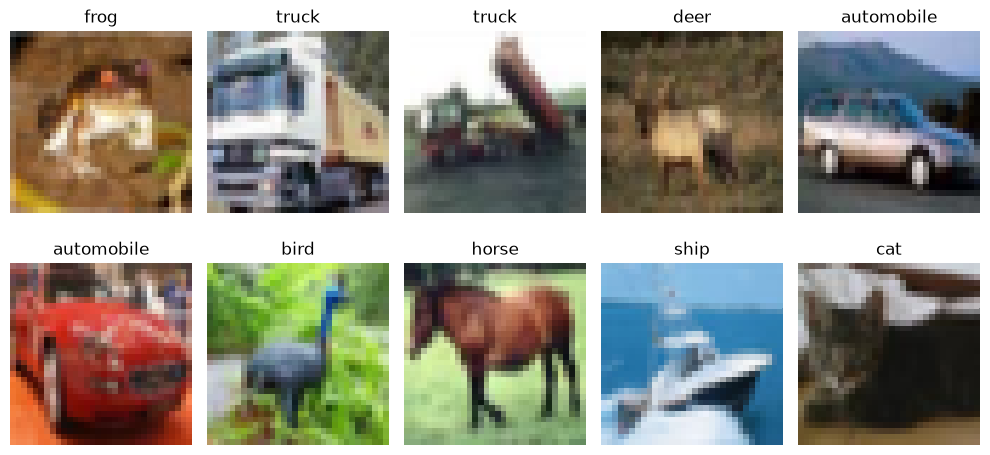

In [3]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.tight_layout()
plt.show()

# 🧹 Preprocessing
We normalize pixel values from **0–255 → 0–1** so training becomes stable.

In [4]:
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

# 🔹 Part 1: ANN Model
ANN treats images as **flat vectors**, so it cannot preserve spatial features.
This helps students understand **why CNN is better for images**.

In [5]:
ann_model = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_history = ann_model.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

c:\Users\ayush\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 17s 22ms/step - accuracy: 0.2662 - loss: 2.0019 - val_accuracy: 0.3388 - val_loss: 1.8416
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 16s 23ms/step - accuracy: 0.3160 - loss: 1.8644 - val_accuracy: 0.3638 - val_loss: 1.7914
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 16s 23ms/step - accuracy: 0.3339 - loss: 1.8204 - val_accuracy: 0.3790 - val_loss: 1.7700
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 19ms/step - accuracy: 0.3552 - loss: 1.7706 - val_accuracy: 0.3920 - val_loss: 1.6975
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 20ms/step - accuracy: 0.3632 - loss: 1.7442 - val_accuracy: 0.3978 - val_loss: 1.7116
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 19ms/step - accuracy: 0.3750 - loss: 1.7171 - val_accuracy: 0.4112 - val_loss: 1.6738
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 19ms/step - accuracy: 0.3767 - loss: 1.7078 - val_accuracy: 0.4160 - val_loss: 1.6590
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 19ms/step - accuracy: 0.3865 - loss: 1.6857 - 

In [6]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy:", ann_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4276 - loss: 1.6111
ANN Test Accuracy: 0.4275999963283539


# 🔹 Part 2: CNN Model
CNN preserves **spatial relationships** using:
- Convolution layers
- Pooling
- Feature extraction
- Hierarchical learning

This is why CNN performs much better for image tasks.

In [7]:
cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

c:\Users\ayush\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 44s 59ms/step - accuracy: 0.4577 - loss: 1.5127 - val_accuracy: 0.5474 - val_loss: 1.2479
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 41s 58ms/step - accuracy: 0.5990 - loss: 1.1400 - val_accuracy: 0.5916 - val_loss: 1.1458
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 40s 56ms/step - accuracy: 0.6675 - loss: 0.9614 - val_accuracy: 0.6528 - val_loss: 0.9984
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 39s 56ms/step - accuracy: 0.7077 - loss: 0.8427 - val_accuracy: 0.6258 - val_loss: 1.1203
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 39s 56ms/step - accuracy: 0.7370 - loss: 0.7513 - val_accuracy: 0.6730 - val_loss: 1.0040
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 39s 55ms/step - accuracy: 0.7666 - loss: 0.6679 - val_accuracy: 0.7158 - val_loss: 0.8911
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 39s 55ms/step - accuracy: 0.7892 - loss: 0.5940 - val_accuracy: 0.7408 - val_loss: 0.7998
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 39s 56ms/step - accuracy: 0.8087 - loss: 0.5447 - 

In [8]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy:", cnn_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.7255 - loss: 0.9213
CNN Test Accuracy: 0.7254999876022339


## 📈 Compare Learning Curves

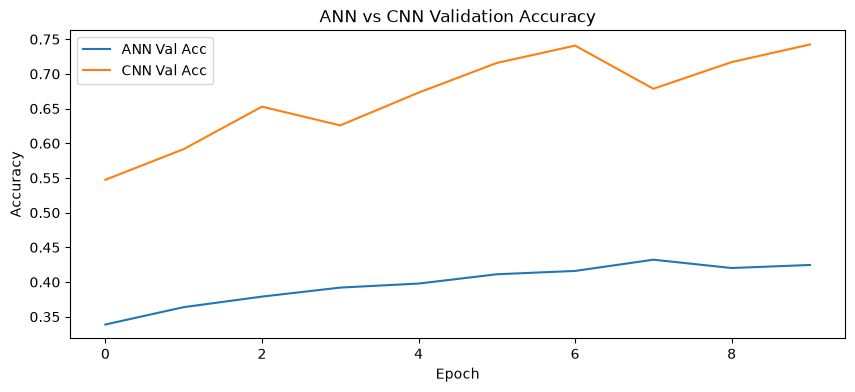

In [9]:
plt.figure(figsize=(10,4))
plt.plot(ann_history.history['val_accuracy'], label='ANN Val Acc')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN vs CNN Validation Accuracy")
plt.legend()
plt.show()

# 🚀 Training Strategy Upgrade: Data Augmentation
This strategy improves generalization by generating transformed images.

In [10]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

aug_cnn_model = models.Sequential([
    data_augmentation,
    layers.Conv2D(32, 3, activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

aug_cnn_model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

# Suggested optional run:
# aug_history = aug_cnn_model.fit(x_train_norm, y_train, epochs=10, validation_split=0.1)

# 📊 Final Comparison Table

In [11]:
comparison = pd.DataFrame({
    "Model": ["ANN", "CNN"],
    "Test Accuracy": [ann_test_acc, cnn_test_acc]
})
comparison

,Model,Test Accuracy
0,ANN,0.4276
1,CNN,0.7255


# 🎓 Student Learning Tasks
Try these tasks after understanding the notebook:

### ✅ Beginner Tasks
1. Increase ANN layers and observe performance
2. Change CNN filters from 32→64→128
3. Increase epochs to 20
4. Add **EarlyStopping**
5. Add **data augmentation training**

## 🧪 Task Implementations
The five beginner tasks below are implemented and run end-to-end, each in its own cell.

### ✅ Task 1: Increase ANN layers and observe performance
We deepen the original 2-hidden-layer ANN into a 4-hidden-layer network and compare test accuracy against the baseline ANN.

In [12]:
# Task 1: Deeper ANN
deep_ann_model = models.Sequential([
    layers.Dense(1024, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

deep_ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

deep_ann_history = deep_ann_model.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

deep_ann_test_loss, deep_ann_test_acc = deep_ann_model.evaluate(x_test_flat, y_test)
print("Deeper ANN Test Accuracy:", deep_ann_test_acc)
print("Baseline ANN Test Accuracy:", ann_test_acc)

c:\Users\ayush\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 37s 51ms/step - accuracy: 0.2502 - loss: 2.0149 - val_accuracy: 0.3158 - val_loss: 1.8749
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 33s 46ms/step - accuracy: 0.3083 - loss: 1.8842 - val_accuracy: 0.3528 - val_loss: 1.8085
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 32s 45ms/step - accuracy: 0.3296 - loss: 1.8335 - val_accuracy: 0.3540 - val_loss: 1.7803
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 32s 45ms/step - accuracy: 0.3420 - loss: 1.7965 - val_accuracy: 0.3860 - val_loss: 1.7329
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 32s 45ms/step - accuracy: 0.3553 - loss: 1.7677 - val_accuracy: 0.3990 - val_loss: 1.7097
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 32s 45ms/step - accuracy: 0.3643 - loss: 1.7466 - val_accuracy: 0.3986 - val_loss: 1.6840
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 31s 45ms/step - accuracy: 0.3752 - loss: 1.7215 - val_accuracy: 0.4166 - val_loss: 1.6729
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 32s 45ms/step - accuracy: 0.3818 - loss: 1.7070 - 

### ✅ Task 2: Change CNN filters from 32 → 64 → 128
The `cnn_model` built above already scales filters as 32 → 64 → 128 across its three convolution blocks. The summary below confirms the filter progression layer by layer.

In [13]:
# Task 2: Confirm the 32 -> 64 -> 128 filter progression in cnn_model
cnn_model.summary()

conv_layers = [l for l in cnn_model.layers if isinstance(l, layers.Conv2D)]
for l in conv_layers:
    print(l.name, "-> filters:", l.filters)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 30, 30, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 13, 13, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,071,200 (4.09 MB)

 Trainable params: 357,002 (1.36 MB)

 Non-trainable params: 192 (768.00 B)

 Optimizer params: 714,006 (2.72 MB)

conv2d -> filters: 32
conv2d_1 -> filters: 64
conv2d_2 -> filters: 128


### ✅ Task 3: Increase epochs to 20
We retrain a fresh copy of the CNN architecture for 20 epochs instead of 10, to see whether validation accuracy keeps improving with more training time.

In [14]:
# Task 3: Train the same CNN architecture for 20 epochs
cnn_model_20 = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model_20.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_history_20 = cnn_model_20.fit(
    x_train_norm, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64
)

cnn_test_loss_20, cnn_test_acc_20 = cnn_model_20.evaluate(x_test_norm, y_test)
print("CNN (20 epochs) Test Accuracy:", cnn_test_acc_20)
print("CNN (10 epochs) Test Accuracy:", cnn_test_acc)

c:\Users\ayush\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 50s 67ms/step - accuracy: 0.4630 - loss: 1.4983 - val_accuracy: 0.4968 - val_loss: 1.3467
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 41s 59ms/step - accuracy: 0.6025 - loss: 1.1314 - val_accuracy: 0.6118 - val_loss: 1.0775
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 40s 57ms/step - accuracy: 0.6667 - loss: 0.9564 - val_accuracy: 0.5864 - val_loss: 1.2197
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 40s 57ms/step - accuracy: 0.7100 - loss: 0.8381 - val_accuracy: 0.6652 - val_loss: 1.0005
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 39s 56ms/step - accuracy: 0.7419 - loss: 0.7435 - val_accuracy: 0.6640 - val_loss: 0.9807
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 41s 58ms/step - accuracy: 0.7674 - loss: 0.6626 - val_accuracy: 0.7300 - val_loss: 0.7940
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 41s 58ms/step - accuracy: 0.7916 - loss: 0.5918 - val_accuracy: 0.7282 - val_loss: 0.8444
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 41s 58ms/step - accuracy: 0.8145 - loss: 0.5256 - 

### ✅ Task 4: Add EarlyStopping
We add Keras' `EarlyStopping` callback (monitoring validation loss, with `restore_best_weights=True`) so training halts once the model stops improving, and train for up to 20 epochs.

In [15]:
# Task 4: EarlyStopping callback
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

cnn_model_es = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model_es.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_history_es = cnn_model_es.fit(
    x_train_norm, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stop]
)

cnn_test_loss_es, cnn_test_acc_es = cnn_model_es.evaluate(x_test_norm, y_test)
print("CNN + EarlyStopping Test Accuracy:", cnn_test_acc_es)
print("Stopped at epoch:", len(cnn_history_es.history['loss']), "out of 20")

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 44s 60ms/step - accuracy: 0.4756 - loss: 1.4813 - val_accuracy: 0.4674 - val_loss: 1.8618
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 40s 57ms/step - accuracy: 0.6165 - loss: 1.1038 - val_accuracy: 0.5888 - val_loss: 1.1844
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 39s 55ms/step - accuracy: 0.6739 - loss: 0.9333 - val_accuracy: 0.5788 - val_loss: 1.2885
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 39s 55ms/step - accuracy: 0.7155 - loss: 0.8166 - val_accuracy: 0.6300 - val_loss: 1.0487
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 38s 54ms/step - accuracy: 0.7450 - loss: 0.7307 - val_accuracy: 0.6900 - val_loss: 0.9340
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 39s 56ms/step - accuracy: 0.7703 - loss: 0.6529 - val_accuracy: 0.6732 - val_loss: 1.0301
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 40s 57ms/step - accuracy: 0.7925 - loss: 0.5859 - val_accuracy: 0.6930 - val_loss: 0.9512
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 39s 56ms/step - accuracy: 0.8143 - loss: 0.5250 - 

### ✅ Task 5: Add data augmentation training
We now actually run the training for `aug_cnn_model` (previously only defined, not trained), reusing the `EarlyStopping` callback from Task 4.

In [16]:
# Task 5: Train the augmented CNN model
aug_history = aug_cnn_model.fit(
    x_train_norm, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stop]
)

aug_test_loss, aug_test_acc = aug_cnn_model.evaluate(x_test_norm, y_test)
print("Augmented CNN Test Accuracy:", aug_test_acc)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 27ms/step - accuracy: 0.3640 - loss: 1.7388 - val_accuracy: 0.4834 - val_loss: 1.4334
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 18s 25ms/step - accuracy: 0.4590 - loss: 1.4978 - val_accuracy: 0.5120 - val_loss: 1.3530
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 17s 25ms/step - accuracy: 0.4975 - loss: 1.4007 - val_accuracy: 0.5496 - val_loss: 1.2447
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 17s 25ms/step - accuracy: 0.5237 - loss: 1.3387 - val_accuracy: 0.5596 - val_loss: 1.2295
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 29ms/step - accuracy: 0.5422 - loss: 1.2937 - val_accuracy: 0.5772 - val_loss: 1.2179
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 29ms/step - accuracy: 0.5546 - loss: 1.2552 - val_accuracy: 0.6234 - val_loss: 1.0570
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 28ms/step - accuracy: 0.5669 - loss: 1.2282 - val_accuracy: 0.6134 - val_loss: 1.0970
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 19s 27ms/step - accuracy: 0.5725 - loss: 1.2087 - 

## 📊 Extended Comparison: All Model Variants
Validation accuracy curves and final test accuracy for every model built in this notebook, including the baseline ANN/CNN and all five task variants.

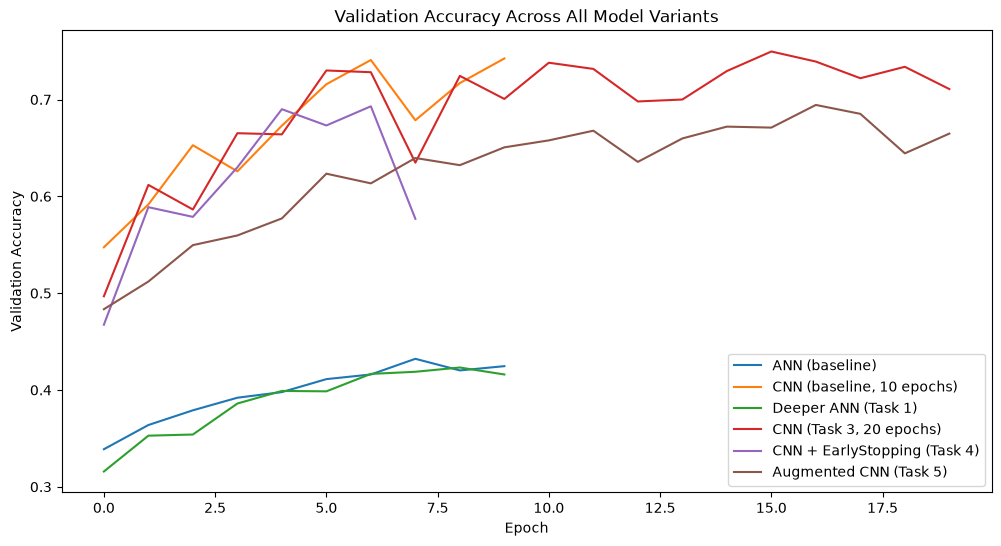

In [17]:
# Extended validation accuracy curve comparison
plt.figure(figsize=(12,6))
plt.plot(ann_history.history['val_accuracy'], label='ANN (baseline)')
plt.plot(cnn_history.history['val_accuracy'], label='CNN (baseline, 10 epochs)')
plt.plot(deep_ann_history.history['val_accuracy'], label='Deeper ANN (Task 1)')
plt.plot(cnn_history_20.history['val_accuracy'], label='CNN (Task 3, 20 epochs)')
plt.plot(cnn_history_es.history['val_accuracy'], label='CNN + EarlyStopping (Task 4)')
plt.plot(aug_history.history['val_accuracy'], label='Augmented CNN (Task 5)')
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy Across All Model Variants")
plt.legend()
plt.show()

In [18]:
# Extended final comparison table across all model variants
extended_comparison = pd.DataFrame({
    "Model": [
        "ANN (baseline)",
        "CNN (baseline, 10 epochs)",
        "Deeper ANN (Task 1)",
        "CNN (Task 3, 20 epochs)",
        "CNN + EarlyStopping (Task 4)",
        "Augmented CNN (Task 5)"
    ],
    "Test Accuracy": [
        ann_test_acc,
        cnn_test_acc,
        deep_ann_test_acc,
        cnn_test_acc_20,
        cnn_test_acc_es,
        aug_test_acc
    ]
})
extended_comparison

,Model,Test Accuracy
0,ANN (baseline),0.4276
1,"CNN (baseline, 10 epochs)",0.7255
2,Deeper ANN (Task 1),0.4213
3,"CNN (Task 3, 20 epochs)",0.6987
4,CNN + EarlyStopping (Task 4),0.6777
5,Augmented CNN (Task 5),0.6836


# ✅ Conclusion
- **ANN works**, but ignores image structure
- **CNN extracts spatial features**, so it performs significantly better
- **Training strategies** like dropout, batch norm, and augmentation improve results
- This project builds strong fundamentals for **computer vision interviews and deep learning projects**